<a href="https://colab.research.google.com/github/Swaroop-analyst/ML-based---Prediction-Visa-Approval-project-using-CRISP-DM-methodology/blob/main/Stock%20price%20prediction%20and%20movement%20direction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# ==============================================================
# ✅ CRISP-DM: Phase 1 — EDA of NSE Stocks vs NIFTY50
# Covers:
# ✅ Load & Align Data (Forward Fill Missing)
# ✅ Univariate EDA
# ✅ Bivariate EDA (Heatmap + Scatter vs NIFTY)
# ✅ Multivariate (PCA + Risk-Return)
# ==============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------------------
# ✅ Load all stock CSVs
# --------------------------------------------------------------
stock_files = [
    "TCS_NS.csv", "BPCL_NS.csv", "HDFCBANK_NS.csv", "HINDUNILVR_NS.csv",
    "ICICIBANK_NS.csv", "INFY_NS.csv", "ITC_NS.csv", "M&M_NS.csv",
    "MARUTI_NS.csv", "RELIANCE_NS.csv"
]

nifty_file = "NIFTY50.csv"  # name can be changed if needed

def read_csv(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().title().replace(" ", "_") for c in df.columns]
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
    if "Close" not in df.columns and "Adj_Close" in df.columns:
        df["Close"] = df["Adj_Close"]
    df = df[["Date", "Close"]]
    return df

stocks = {}
for file in stock_files:
    stocks[file.replace(".csv","")] = read_csv(file)

nifty = read_csv(nifty_file)

# --------------------------------------------------------------
# ✅ Merge all Close prices into one DataFrame
# --------------------------------------------------------------
all_data = nifty.rename(columns={"Close":"NIFTY50"}).set_index("Date")

for name, df in stocks.items():
    all_data[name] = df.set_index("Date")["Close"]

# Forward fill missing data ✅
all_data = all_data.ffill().dropna()

# Create the processed data directory if it doesn't exist
PROC_PATH = "data/processed"
os.makedirs(PROC_PATH, exist_ok=True)

# Save the merged data to a CSV file
all_data.to_csv(os.path.join(PROC_PATH, "cleaned_prices.csv"))


# Compute daily returns
returns = all_data.pct_change().dropna()

print("✅ Data Loaded and Aligned Successfully!")
print(all_data.tail())

✅ Data Loaded and Aligned Successfully!
                NIFTY50       TCS_NS     BPCL_NS  HDFCBANK_NS  HINDUNILVR_NS  \
Date                                                                           
2025-10-23  25891.40039  3073.199951  331.299988  1008.799988    2601.600098   
2025-10-24  25795.15039  3063.199951  330.450012   994.750000    2516.399902   
2025-10-27  25966.05078  3084.899902  343.000000  1002.950012    2511.800049   
2025-10-28  25936.19922  3057.899902  340.649994  1003.549988    2497.100098   
2025-10-29  26053.90039  3057.600098  348.100006  1007.849976    2488.100098   

            ICICIBANK_NS      INFY_NS      ITC_NS       M&M_NS  MARUTI_NS  \
Date                                                                        
2025-10-23   1363.699951  1505.453247  415.950012  3623.600098    16393.0   
2025-10-24   1377.699951  1502.400024  416.799988  3625.000000    16274.0   
2025-10-27   1377.599976  1504.500000  420.649994  3611.600098    16388.0   
2025-10-28   1

Summary Stats (Returns):
                count      mean       std       min       25%       50%  \
NIFTY50        1235.0  0.000690  0.008940 -0.059294 -0.004011  0.000892   
TCS_NS         1235.0  0.000299  0.013168 -0.063535 -0.006706 -0.000070   
BPCL_NS        1235.0  0.001011  0.017697 -0.129025 -0.008730  0.000234   
HDFCBANK_NS    1235.0  0.000567  0.013724 -0.084358 -0.006574  0.000622   
HINDUNILVR_NS  1235.0  0.000272  0.012779 -0.074004 -0.006802 -0.000145   
ICICIBANK_NS   1235.0  0.001129  0.014501 -0.076336 -0.006407  0.000805   
INFY_NS        1235.0  0.000496  0.015295 -0.094227 -0.008269  0.000553   
ITC_NS         1235.0  0.001013  0.013053 -0.080876 -0.006008  0.000487   
M&M_NS         1235.0  0.001653  0.018325 -0.066143 -0.009062  0.001175   
MARUTI_NS      1235.0  0.000807  0.014850 -0.065990 -0.007066  0.000095   
RELIANCE_NS    1235.0  0.000508  0.014749 -0.086177 -0.008165  0.000791   

                    75%       max  
NIFTY50        0.005943  0.047424  
TC

<Figure size 1400x600 with 0 Axes>

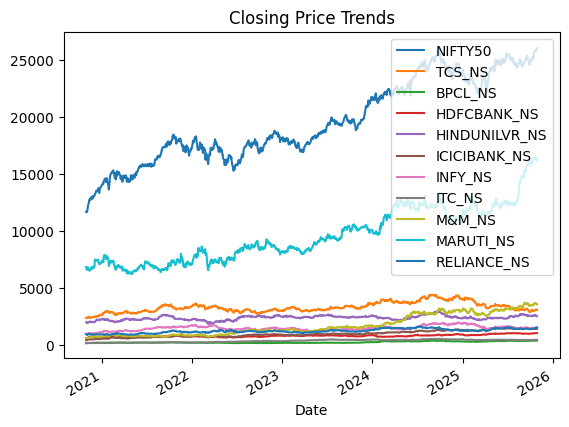

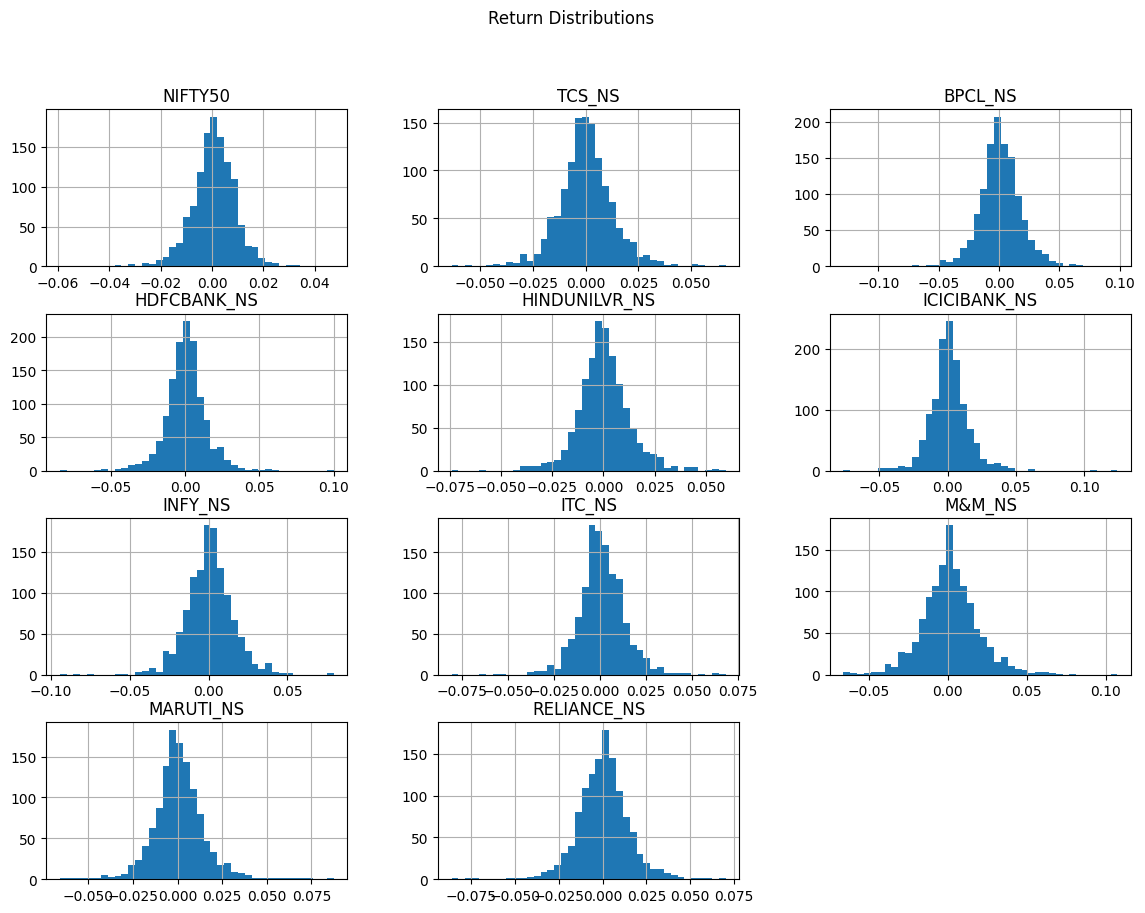

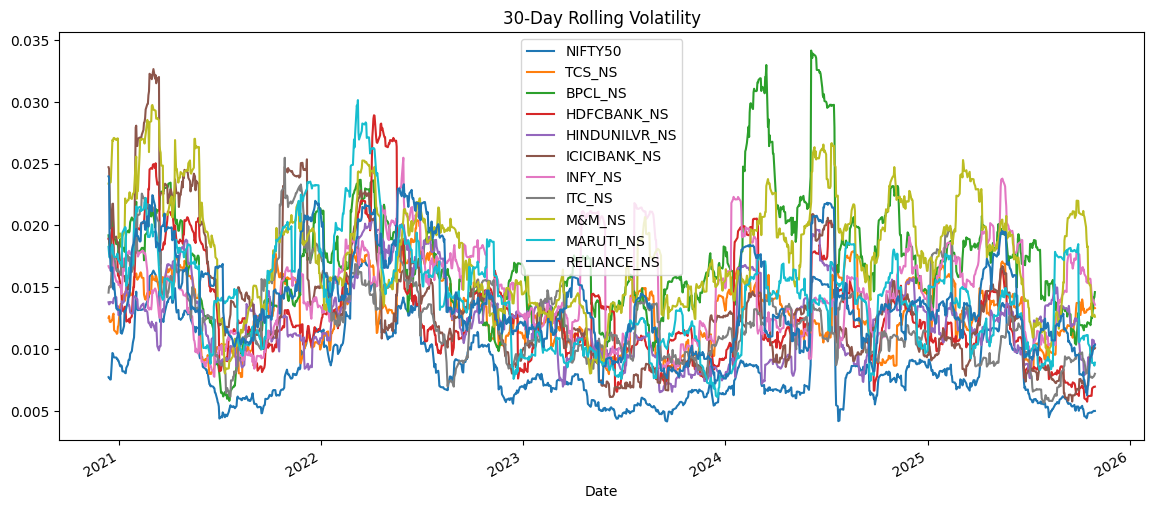

In [18]:
#Univariate EDA

# --------------------------------------------------------------
# ✅ Summary statistics
# --------------------------------------------------------------
summary_stats = returns.describe().T
print("Summary Stats (Returns):")
print(summary_stats)

summary_stats.to_csv("summary_stats.csv")

# Plot trends
plt.figure(figsize=(14,6))
all_data.plot(title="Closing Price Trends")
plt.show()

# Plot histograms of returns
returns.hist(bins=40, figsize=(14,10))
plt.suptitle("Return Distributions")
plt.show()

# Rolling volatility
vol = returns.rolling(30).std()
vol.plot(figsize=(14,6), title="30-Day Rolling Volatility")
plt.show()


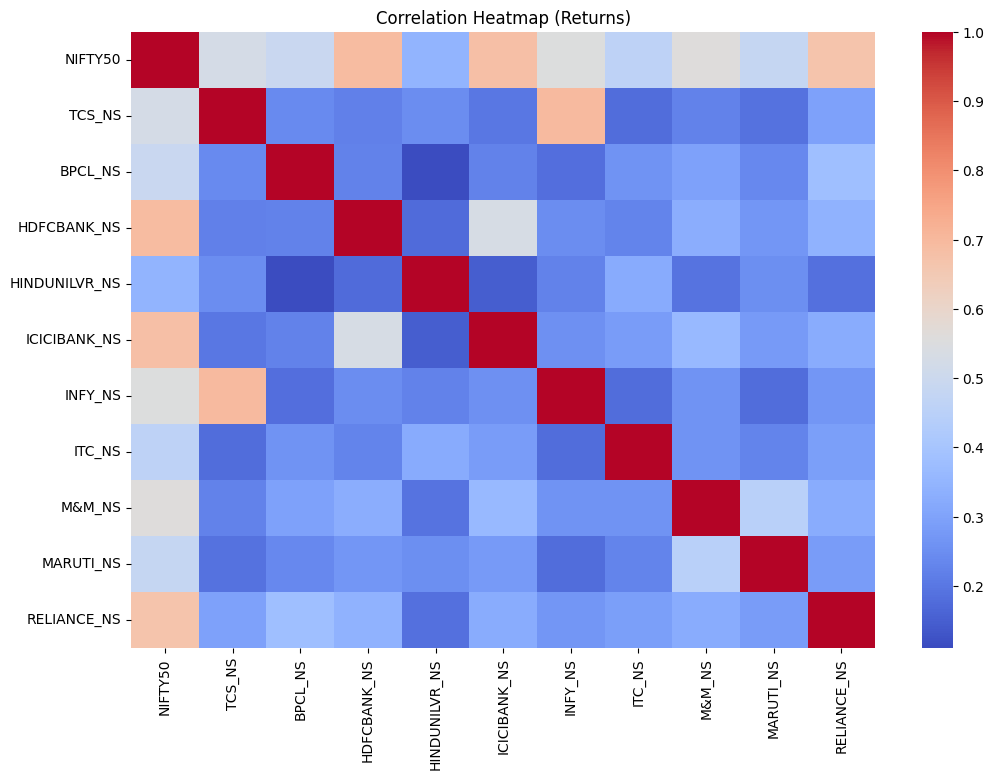

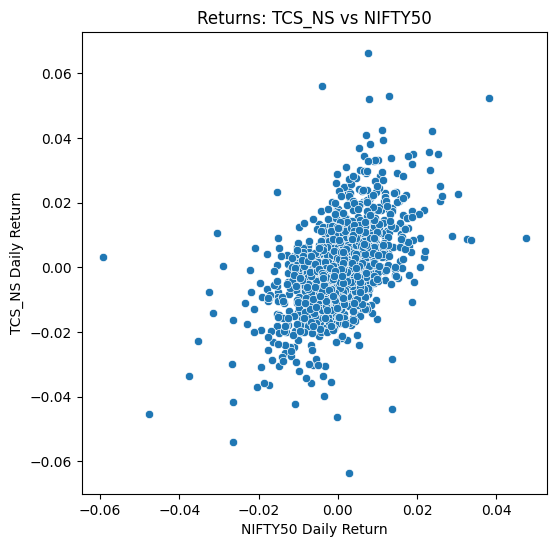

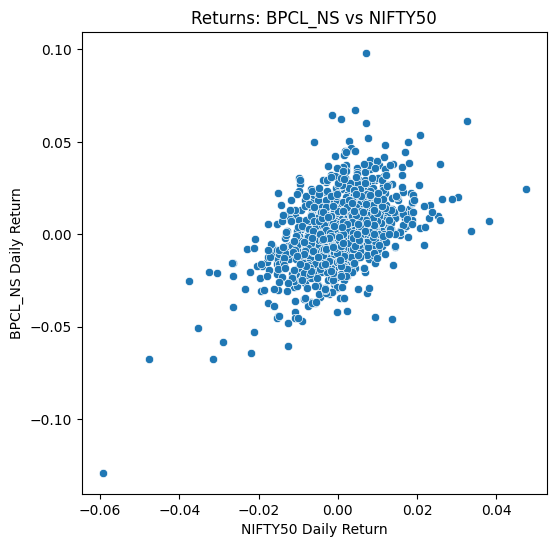

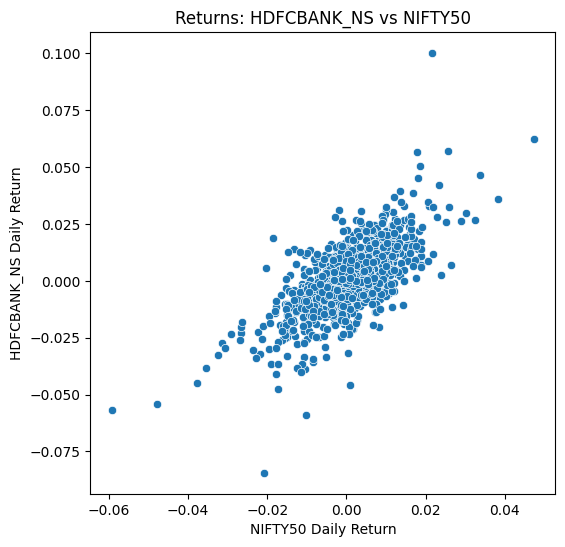

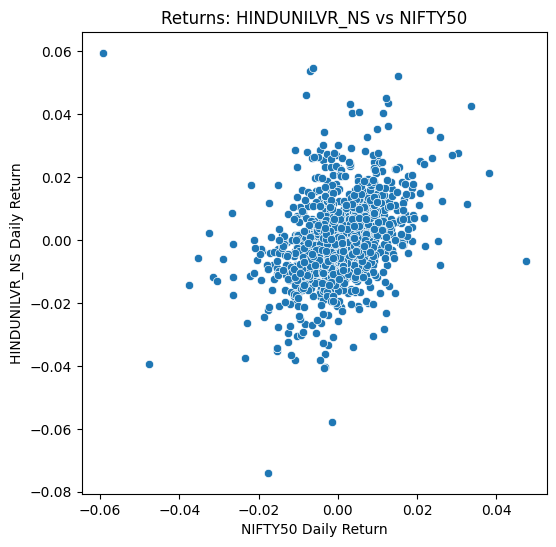

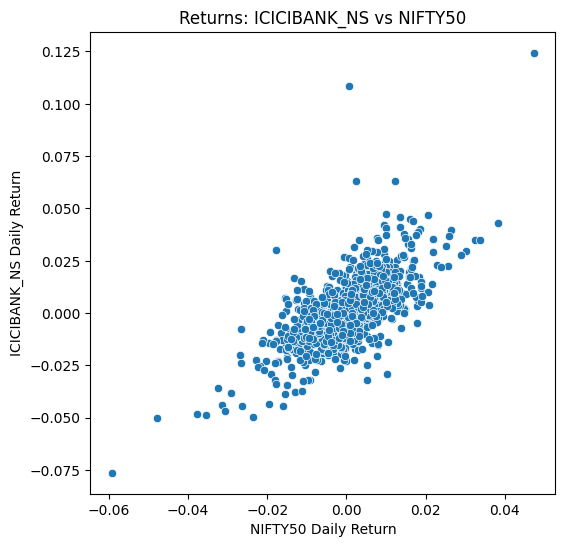

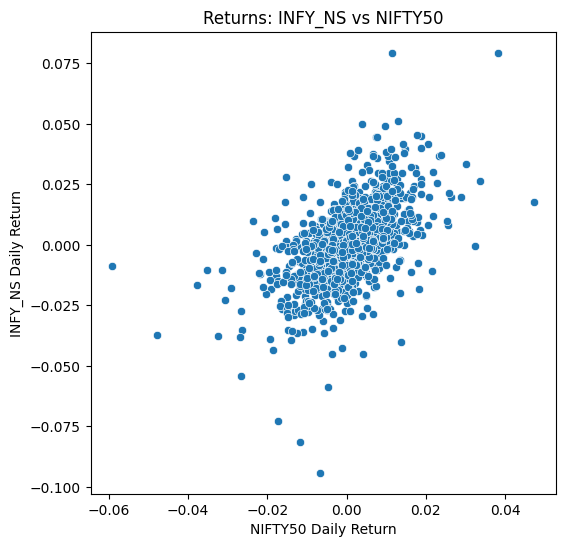

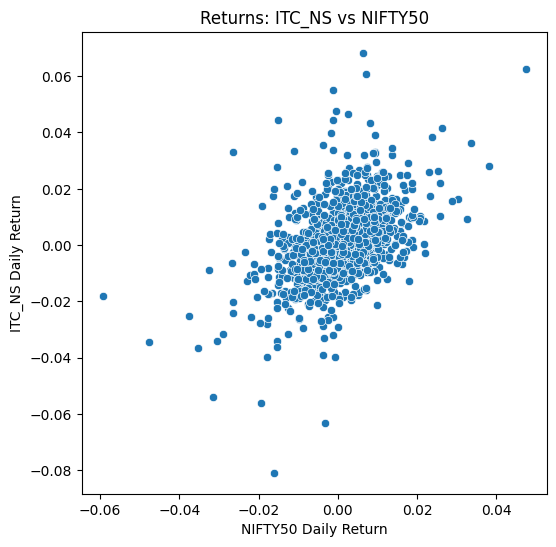

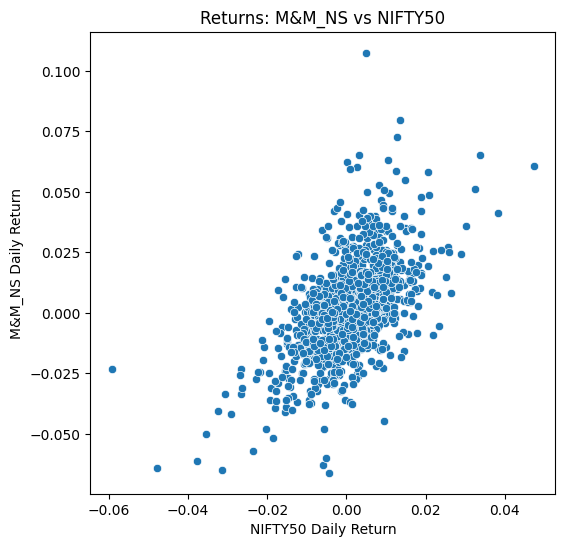

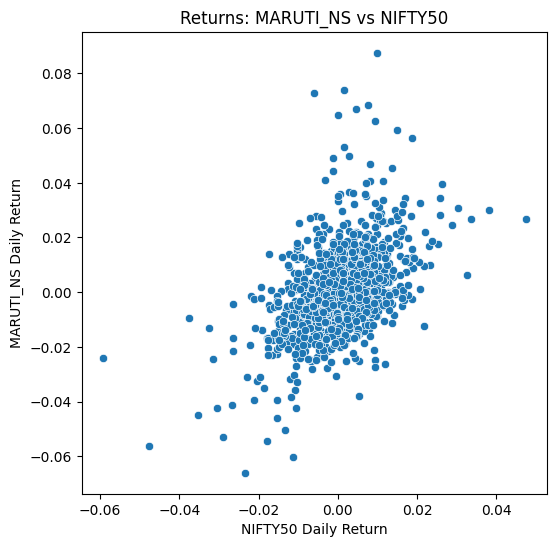

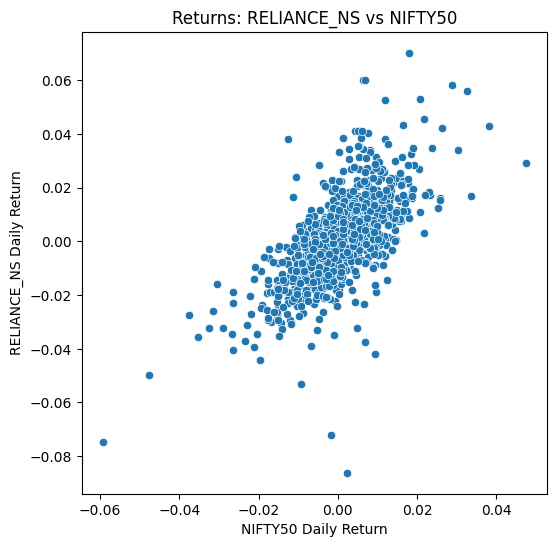

In [19]:
#Bivariate EDA — Correlations with NIFTY

# --------------------------------------------------------------
# ✅ Correlation Heatmap
# --------------------------------------------------------------
plt.figure(figsize=(12,8))
sns.heatmap(returns.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Returns)")
plt.show()

# ✅ Scatter vs NIFTY
for col in returns.columns[1:]:
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=returns["NIFTY50"], y=returns[col])
    plt.title(f"Returns: {col} vs NIFTY50")
    plt.xlabel("NIFTY50 Daily Return")
    plt.ylabel(f"{col} Daily Return")
    plt.show()


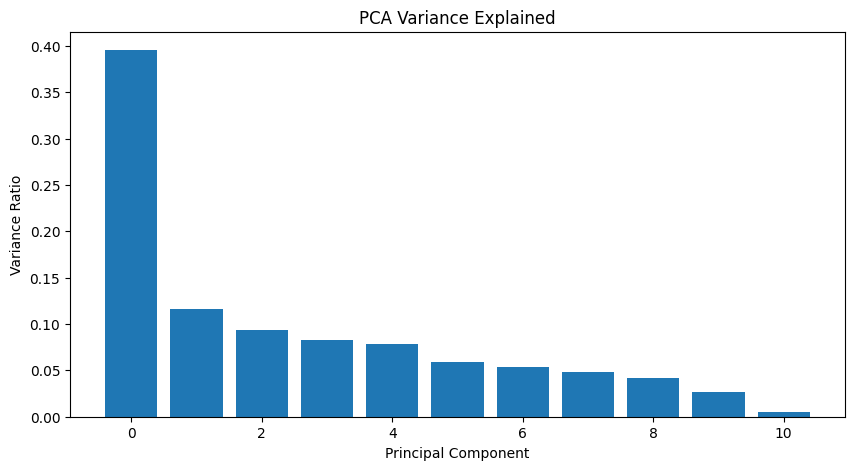

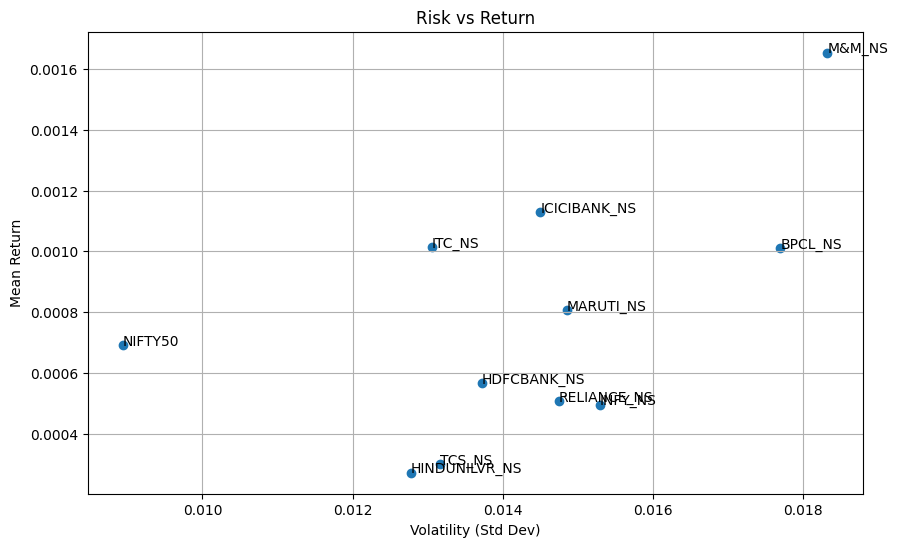

In [20]:
#Multivariate Analysis (PCA + Risk vs Return)

# --------------------------------------------------------------
# ✅ PCA on returns
# --------------------------------------------------------------
scaler = StandardScaler()
scaled_ret = scaler.fit_transform(returns)

pca = PCA()
pca.fit(scaled_ret)

expl_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10,5))
plt.bar(range(len(expl_variance)), expl_variance)
plt.title("PCA Variance Explained")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.show()

# --------------------------------------------------------------
# ✅ Risk vs Return Plot (Mean vs Std Dev)
# --------------------------------------------------------------
risk = returns.std()
mean_ret = returns.mean()

plt.figure(figsize=(10,6))
plt.scatter(risk, mean_ret)

for i, txt in enumerate(returns.columns):
    plt.annotate(txt, (risk[i], mean_ret[i]))

plt.title("Risk vs Return")
plt.xlabel("Volatility (Std Dev)")
plt.ylabel("Mean Return")
plt.grid(True)
plt.show()


In [21]:
returns.to_csv("cleaned_returns.csv")
all_data.to_csv("cleaned_prices.csv")


In [22]:
# ==============================================================
# ✅ CRISP-DM Phase 2: Forecasting (ETS + SARIMAX with NIFTY exog)
# ==============================================================
# Author : Swaroop Narayan
# Target : Predict next-30-day prices for multiple NSE stocks vs NIFTY benchmark
# ==============================================================

import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# --------------------------------------------------------------
# 1️⃣  Project setup
# --------------------------------------------------------------
RAW_PATH  = "data/raw"
PROC_PATH = "data/processed"
FIG_PATH  = "figures"
os.makedirs(PROC_PATH, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)

FORECAST_HORIZON = 30  # ← Option C

# --------------------------------------------------------------
# 2️⃣  Utility functions
# --------------------------------------------------------------
def read_csv(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().title().replace(" ", "_") for c in df.columns]
    if "Date" not in df.columns:
        for c in ["Datetime","Timestamp"]:
            if c in df.columns:
                df = df.rename(columns={c:"Date"})
                break
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
    if "Close" not in df.columns and "Adj_Close" in df.columns:
        df["Close"] = df["Adj_Close"]
    return df[["Date","Close"]]

def build_future_index(last_date, steps):
    return pd.date_range(last_date + pd.Timedelta(days=1), periods=steps, freq="D")

def backtest_ets(series, horizon=1, window_k=120):
    s = series.dropna()
    preds = []
    start = len(s) - window_k if len(s) > window_k else 0
    for t in range(start, len(s)-horizon+1):
        y_train, y_test = s.iloc[:t], s.iloc[t:t+horizon]
        try:
            m = ExponentialSmoothing(y_train, trend="add", seasonal=None).fit(optimized=True)
            p = m.forecast(steps=horizon)
            preds.append((y_test.index[-1], y_test.iloc[-1], float(p.iloc[-1])))
        except Exception:
            pass
    out = pd.DataFrame(preds, columns=["ds","y_true","y_pred"]).set_index("ds")
    out["residual"] = out["y_true"] - out["y_pred"]
    return out

def backtest_sarimax(series, exog, horizon=1, window_k=60, stride=5):
    s = series.dropna()
    ex = exog.reindex(s.index).fillna(0.0)
    preds = []
    start = len(s) - window_k if len(s) > window_k else 0
    for t in range(start, len(s)-horizon+1, stride):
        y_train, y_test = s.iloc[:t], s.iloc[t:t+horizon]
        ex_train, ex_test = ex.iloc[:t], ex.iloc[t:t+horizon]
        try:
            m = SARIMAX(y_train, order=(1,1,1), exog=ex_train,
                        enforce_stationarity=False, enforce_invertibility=False)
            r = m.fit(disp=False)
            p = r.forecast(steps=horizon, exog=ex_test)
            preds.append((y_test.index[-1], y_test.iloc[-1], float(p.iloc[-1])))
        except Exception:
            pass
    out = pd.DataFrame(preds, columns=["ds","y_true","y_pred"]).set_index("ds")
    out["residual"] = out["y_true"] - out["y_pred"]
    return out

# --------------------------------------------------------------
# 3️⃣  Load merged data (from Phase 1)
# --------------------------------------------------------------
merged = pd.read_csv(os.path.join(PROC_PATH,"cleaned_prices.csv"), parse_dates=["Date"]).set_index("Date")
nifty_ret = merged["NIFTY50"].pct_change().fillna(0.0)

forecast_rows = []

# --------------------------------------------------------------
# 4️⃣  Forecasting loop per stock
# --------------------------------------------------------------
for sym in [c for c in merged.columns if c != "NIFTY50"]:
    s = merged[sym].dropna()
    exog = nifty_ret.reindex(s.index).fillna(0.0)

    # --- Backtest metrics ---
    ets_bt = backtest_ets(s)
    ets_mae  = np.mean(np.abs(ets_bt["residual"])) if not ets_bt.empty else np.nan
    ets_rmse = np.sqrt(np.mean(ets_bt["residual"]**2)) if not ets_bt.empty else np.nan

    sar_bt = backtest_sarimax(s, exog)
    sar_mae  = np.mean(np.abs(sar_bt["residual"])) if not sar_bt.empty else np.nan
    sar_rmse = np.sqrt(np.mean(sar_bt["residual"]**2)) if not sar_bt.empty else np.nan

    # --- Train full models & forecast next 30 days ---
    # ETS
    try:
        ets_model = ExponentialSmoothing(s, trend="add", seasonal=None).fit(optimized=True)
        ets_fc = ets_model.forecast(FORECAST_HORIZON)
    except Exception:
        ets_fc = pd.Series(index=build_future_index(s.index.max(), FORECAST_HORIZON), dtype=float)

    # SARIMAX
    try:
        sar_model = SARIMAX(s, order=(1,1,1), exog=exog,
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        future_idx = build_future_index(s.index.max(), FORECAST_HORIZON)
        future_ex  = pd.Series(0.0, index=future_idx, name="nifty_ret")
        sar_fc = sar_model.forecast(steps=FORECAST_HORIZON, exog=future_ex)
    except Exception:
        future_idx = build_future_index(s.index.max(), FORECAST_HORIZON)
        sar_fc = pd.Series(index=future_idx, dtype=float)

    # --- Save results ---
    pd.DataFrame({
        "ETS_forecast": ets_fc,
        "SARIMAX_forecast": sar_fc
    }).to_csv(os.path.join(PROC_PATH, f"{sym}_30day_forecasts.csv"))

    # --- Plot last 200 days + forecast ---
    plt.figure(figsize=(10,5))
    s.iloc[-200:].plot(label="Actual")
    ets_fc.plot(label="ETS Forecast")
    sar_fc.plot(label="SARIMAX Forecast")
    plt.title(f"{sym} – 30-Day Forecasts vs History")
    plt.xlabel("Date"); plt.ylabel("Price")
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(FIG_PATH, f"{sym}_forecast_30d.png"))
    plt.close()

    forecast_rows.append({
        "symbol": sym,
        "ETS_MAE": ets_mae, "ETS_RMSE": ets_rmse,
        "SARIMAX_MAE": sar_mae, "SARIMAX_RMSE": sar_rmse
    })

# --------------------------------------------------------------
# 5️⃣  Save metrics + summary
# --------------------------------------------------------------
metrics = pd.DataFrame(forecast_rows)
metrics.to_csv(os.path.join(PROC_PATH,"forecast_backtest_metrics.csv"), index=False)
print(metrics)

print("\n✅ Forecasting complete! 30-day CSVs + plots in data/processed and figures/.")

# --------------------------------------------------------------
# 6️⃣  Optional: quick view of top performing model per stock
# --------------------------------------------------------------
best = metrics.loc[metrics.groupby("symbol")["SARIMAX_RMSE"].idxmin(), ["symbol","SARIMAX_RMSE"]]
print("\nBest (SARIMAX lowest RMSE):")
print(best)


          symbol     ETS_MAE    ETS_RMSE  SARIMAX_MAE  SARIMAX_RMSE
0         TCS_NS   28.349399   39.354355    28.826737     37.887399
1        BPCL_NS    3.459766    4.690190     4.476254      5.660185
2    HDFCBANK_NS    6.156949    8.220074     3.032735      3.952724
3  HINDUNILVR_NS   20.891849   28.282361    24.500629     33.026137
4   ICICIBANK_NS    9.762814   13.546440     6.393976      8.172778
5        INFY_NS   16.023457   22.828687    24.126445     32.873284
6         ITC_NS    2.855580    3.660879     2.727162      3.351094
7         M&M_NS   36.585727   49.947020    52.442150     64.083081
8      MARUTI_NS  116.339265  172.115400   183.611811    338.742466
9    RELIANCE_NS   12.012281   16.035769     8.237585     10.514437

✅ Forecasting complete! 30-day CSVs + plots in data/processed and figures/.

Best (SARIMAX lowest RMSE):
          symbol  SARIMAX_RMSE
1        BPCL_NS      5.660185
2    HDFCBANK_NS      3.952724
3  HINDUNILVR_NS     33.026137
4   ICICIBANK_NS      

In [23]:
# 1_imports_and_config.py
import os
import glob
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Config
PROC_PRICES_PATH = "cleaned_prices.csv"   # adapt if your file name/path differs
RAW_DIR = "data/raw"                      # fallback if cleaned file not found
OUT_DIR = "phase3_output"
FIG_DIR = os.path.join(OUT_DIR, "figures")
METRICS_DIR = os.path.join(OUT_DIR, "metrics")
PRED_DIR = os.path.join(OUT_DIR, "predictions")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS = 5  # TimeSeriesSplit folds


In [24]:
# 2_load_and_features.py
import warnings
warnings.filterwarnings("ignore")

def read_yahoo_csv(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().title().replace(" ", "_") for c in df.columns]
    if "Date" not in df.columns:
        for c in ("Datetime", "Timestamp"):
            if c in df.columns:
                df = df.rename(columns={c: "Date"})
                break
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
    if "Close" not in df.columns and "Adj_Close" in df.columns:
        df["Close"] = df["Adj_Close"]
    return df[["Date", "Close"]]

# Load merged prices (Phase 1). If missing, attempt to reconstruct from raw csvs.
if os.path.exists(PROC_PRICES_PATH):
    merged = pd.read_csv(PROC_PRICES_PATH, parse_dates=["Date"]).set_index("Date")
else:
    # Rebuild quickly
    print("cleaned_prices.csv not found — attempting to build from raw files in data/raw/")
    stock_files = sorted(glob.glob(os.path.join(RAW_DIR, "*_NS.csv")))
    nifty_path = os.path.join(RAW_DIR, "NIFTY50.csv")
    if not stock_files or not os.path.exists(nifty_path):
        raise FileNotFoundError("No cleaned_prices.csv and data/raw missing *_NS.csv or NIFTY50.csv")
    nifty = read_yahoo_csv(nifty_path).rename(columns={"Close": "NIFTY50"}).set_index("Date")
    merged = nifty.copy()
    for p in stock_files:
        name = os.path.basename(p).replace(".csv", "")
        df = read_yahoo_csv(p).set_index("Date")
        merged[name] = df["Close"]
    merged = merged.sort_index().ffill().dropna(how="all")
    merged.to_csv(PROC_PRICES_PATH)
    print("Rebuilt cleaned_prices.csv and saved.")

# Forward-fill and final alignment
merged = merged.sort_index().ffill().dropna()
print(f"Loaded merged data with columns: {list(merged.columns)}")
print("Date range:", merged.index.min(), "to", merged.index.max())

# compute features function
def compute_features(series, nifty_series=None):
    s = series.astype(float).copy()
    df = pd.DataFrame(index=s.index)
    # returns
    df["ret_1"] = s.pct_change(1)
    df["ret_2"] = s.pct_change(2)
    df["ret_5"] = s.pct_change(5)
    # rolling stats
    df["sma_5"] = s.rolling(5).mean()
    df["sma_20"] = s.rolling(20).mean()
    df["sma_gap_5"] = s / df["sma_5"] - 1
    df["sma_gap_20"] = s / df["sma_20"] - 1
    # RSI(14)
    delta = s.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss.replace(0, np.nan)
    df["rsi_14"] = 100 - (100 / (1 + rs))
    # MACD
    ema12 = s.ewm(span=12, adjust=False).mean()
    ema26 = s.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    df["macd"] = macd
    df["macd_signal"] = macd.ewm(span=9, adjust=False).mean()
    df["macd_hist"] = df["macd"] - df["macd_signal"]
    # volatility
    df["vol_10"] = s.pct_change().rolling(10).std()
    # NIFTY return as exogenous feature
    if nifty_series is not None:
        df["nifty_ret_1"] = nifty_series.reindex(s.index).pct_change().fillna(0.0)
    return df

# Build dataset per symbol
datasets = {}  # symbol -> dataframe with features + 'y' target
nifty_series = merged["NIFTY50"] if "NIFTY50" in merged.columns else None

for sym in merged.columns:
    if sym == "NIFTY50": continue
    prices = merged[sym].dropna()
    feats = compute_features(prices, nifty_series)
    # target: next-day direction
    target = (prices.pct_change().shift(-1) > 0).astype(int).rename("y")
    df = pd.concat([feats, target], axis=1).dropna()
    if len(df) < 300:
        print(f"Skipping {sym}: not enough data after feature engineering ({len(df)} rows).")
        continue
    datasets[sym] = df
    print(f"Prepared dataset for {sym}: {df.shape[0]} rows, {df.shape[1]-1} features")


Loaded merged data with columns: ['NIFTY50', 'TCS_NS', 'BPCL_NS', 'HDFCBANK_NS', 'HINDUNILVR_NS', 'ICICIBANK_NS', 'INFY_NS', 'ITC_NS', 'M&M_NS', 'MARUTI_NS', 'RELIANCE_NS']
Date range: 2020-10-29 00:00:00 to 2025-10-29 00:00:00
Prepared dataset for TCS_NS: 1217 rows, 13 features
Prepared dataset for BPCL_NS: 1217 rows, 13 features
Prepared dataset for HDFCBANK_NS: 1217 rows, 13 features
Prepared dataset for HINDUNILVR_NS: 1217 rows, 13 features
Prepared dataset for ICICIBANK_NS: 1217 rows, 13 features
Prepared dataset for INFY_NS: 1217 rows, 13 features
Prepared dataset for ITC_NS: 1217 rows, 13 features
Prepared dataset for M&M_NS: 1217 rows, 13 features
Prepared dataset for MARUTI_NS: 1217 rows, 13 features
Prepared dataset for RELIANCE_NS: 1217 rows, 13 features


In [25]:
#Modeling & TimeSeriesSplit evaluation

# 3_model_training_and_evaluation.py

models = {
    "LogisticRegression": LogisticRegression(max_iter=400, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVC": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=15)
}

overall_metrics = []  # rows of dicts
per_symbol_predictions = {}  # to save per-symbol per-fold preds

for sym, df in datasets.items():
    X = df.drop(columns=["y"])
    y = df["y"]
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    symbol_rows = []
    preds_all = []  # to record for CSV: date, true, pred, prob, model, fold

    for mname, m in models.items():
        accs, f1s, rocs = [], [], []
        fold_idx = 0
        for train_idx, test_idx in tscv.split(X):
            Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
            ytr, yte = y.iloc[train_idx], y.iloc[test_idx]

            # pipeline (scale for linear/knn/svc)
            if mname in ("LogisticRegression", "SVC", "KNN"):
                pipe = Pipeline([("scaler", StandardScaler()), ("clf", m)])
            else:
                pipe = Pipeline([("clf", m)])

            pipe.fit(Xtr, ytr)
            ypred = pipe.predict(Xte)
            try:
                yprob = pipe.predict_proba(Xte)[:, 1]
            except Exception:
                # fallback to decision_function if available for ROC
                if hasattr(pipe, "decision_function"):
                    yprob = pipe.decision_function(Xte)
                else:
                    yprob = np.zeros(len(yte))

            acc = accuracy_score(yte, ypred)
            f1 = f1_score(yte, ypred)
            # ROC AUC only when both classes present
            try:
                roc = roc_auc_score(yte, yprob) if len(np.unique(yte)) > 1 else np.nan
            except Exception:
                roc = np.nan

            accs.append(acc); f1s.append(f1); rocs.append(roc)

            # save per-fold predictions
            fold_dates = Xte.index
            for i, dt in enumerate(fold_dates):
                preds_all.append({
                    "date": dt,
                    "symbol": sym,
                    "model": mname,
                    "fold": fold_idx,
                    "y_true": int(yte.iloc[i]),
                    "y_pred": int(ypred[i]),
                    "y_prob": float(yprob[i]) if hasattr(yprob, "__len__") else float(yprob)
                })
            fold_idx += 1

        symbol_rows.append({
            "symbol": sym,
            "model": mname,
            "accuracy_mean": np.nanmean(accs),
            "accuracy_std": np.nanstd(accs),
            "f1_mean": np.nanmean(f1s),
            "f1_std": np.nanstd(f1s),
            "roc_auc_mean": np.nanmean(rocs),
            "roc_auc_std": np.nanstd(rocs)
        })

    # save per-symbol model metrics
    symbol_metrics_df = pd.DataFrame(symbol_rows)
    symbol_metrics_df.to_csv(os.path.join(METRICS_DIR, f"{sym}_classification_metrics.csv"), index=False)

    # save per-symbol predictions
    preds_df = pd.DataFrame(preds_all).sort_values(["model","fold","date"])
    preds_df.to_csv(os.path.join(PRED_DIR, f"{sym}_predictions.csv"), index=False)

    # append to overall metrics
    overall_metrics.append(symbol_metrics_df)
    per_symbol_predictions[sym] = preds_df

# overall summary
summary_df = pd.concat(overall_metrics, ignore_index=True)
summary_df.to_csv(os.path.join(METRICS_DIR, "classification_summary_all_symbols.csv"), index=False)
print("Saved classification metrics and per-symbol predictions.")


Saved classification metrics and per-symbol predictions.


In [26]:
#Quick visualizations & reports

# 4_plots_and_report.py
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

report_lines = [f"# Phase 3 — Direction Classification Report\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n"]

summary = pd.read_csv(os.path.join(METRICS_DIR, "classification_summary_all_symbols.csv"))
# For each symbol, pick best model by f1_mean and plot confusion matrix on last fold predictions
for sym in summary['symbol'].unique():
    sym_df = summary[summary['symbol'] == sym]
    best = sym_df.sort_values('f1_mean', ascending=False).iloc[0]
    model_name = best['model']
    report_lines.append(f"## {sym}\nBest model (by F1 mean): **{model_name}**\n")
    # load preds
    preds = pd.read_csv(os.path.join(PRED_DIR, f"{sym}_predictions.csv"))
    preds_model = preds[preds['model'] == model_name]
    # take last fold
    last_fold = preds_model['fold'].max()
    last_preds = preds_model[preds_model['fold'] == last_fold].sort_values('date')
    y_true = last_preds['y_true'].values
    y_pred = last_preds['y_pred'].values

    # confusion matrix plot
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    fig, ax = plt.subplots(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{sym} — Confusion Matrix ({model_name}, fold {last_fold})')
    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, f"{sym}_{model_name}_confusion_lastfold.png")
    fig.savefig(fig_path)
    plt.close(fig)

    # classification report
    crep = classification_report(y_true, y_pred, digits=4)
    report_lines.append("### Last-fold classification report\n```\n" + crep + "\n```\n")
    report_lines.append(f"Confusion matrix saved: {fig_path}\n")

# Save report
with open(os.path.join(OUT_DIR, "Phase3_Direction_Report.md"), "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Plots and report generated. See Phase3_Direction_Report.md and confusion matrix images.")


Plots and report generated. See Phase3_Direction_Report.md and confusion matrix images.
